In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shif t+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ieee-fraud-detection/sample_submission.csv
/kaggle/input/ieee-fraud-detection/test_identity.csv
/kaggle/input/ieee-fraud-detection/train_identity.csv
/kaggle/input/ieee-fraud-detection/test_transaction.csv
/kaggle/input/ieee-fraud-detection/train_transaction.csv


In [2]:
# Load data
train = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_transaction.csv')
identity = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_identity.csv')
df = train.merge(identity, how='left', on='TransactionID')

In [3]:
# Basic info
print(df.shape)
print(df.dtypes.value_counts())
print(df['isFraud'].value_counts(normalize=True))

(590540, 434)
float64    399
object      31
int64        4
Name: count, dtype: int64
isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


In [4]:

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Plot class distribution

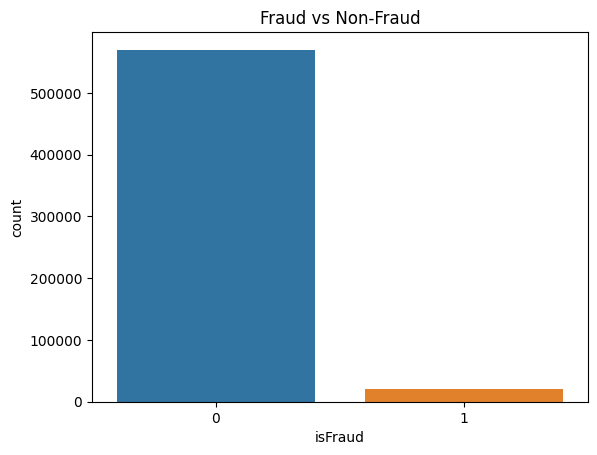

In [8]:
# Plot class distribution

sns.countplot(x='isFraud', data=df)
plt.title('Fraud vs Non-Fraud')
plt.show()

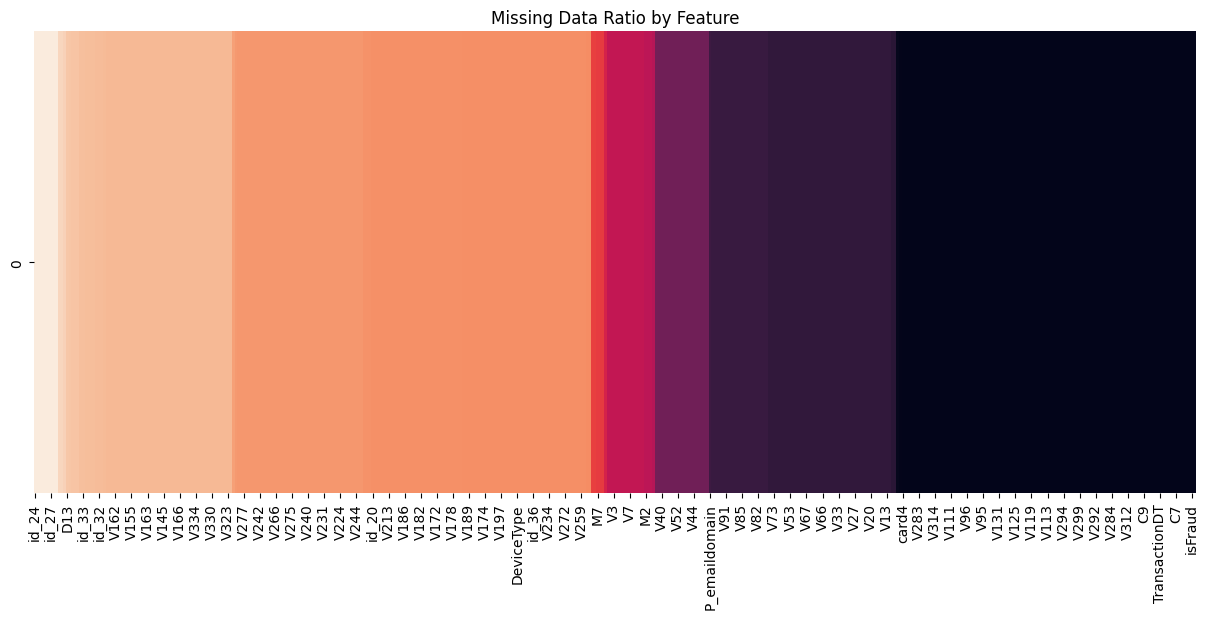

In [9]:
# Missing value heatmap
plt.figure(figsize=(15, 6))
sns.heatmap(df.isnull().mean().sort_values(ascending=False).to_frame().T, cbar=False)
plt.title('Missing Data Ratio by Feature')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

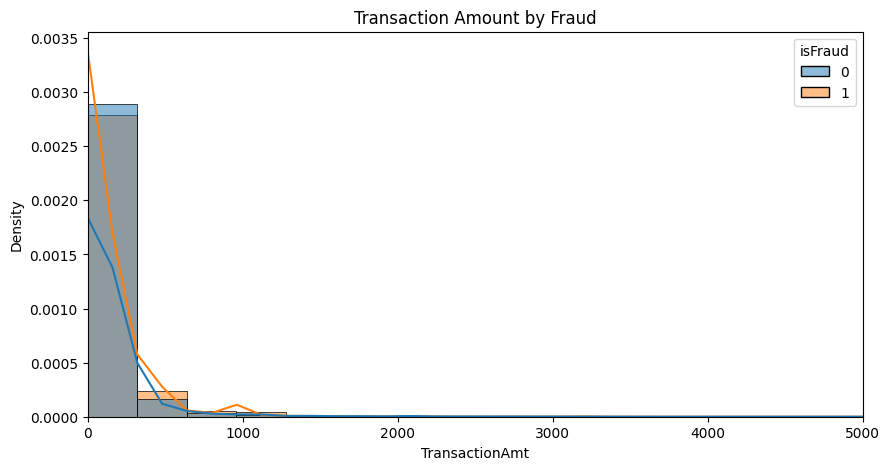

In [10]:
# Transaction Amount by Fraud
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='TransactionAmt', hue='isFraud', bins=100, kde=True, stat='density', common_norm=False)
plt.xlim(0, 5000)
plt.title('Transaction Amount by Fraud')
plt.show()

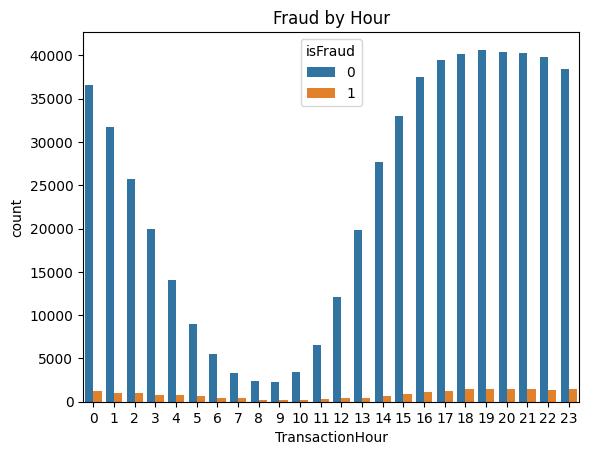

In [11]:
# Time-based fraud (TransactionDT is in seconds)
df['TransactionHour'] = (df['TransactionDT'] // 3600) % 24
sns.countplot(x='TransactionHour', hue='isFraud', data=df)
plt.title('Fraud by Hour')
plt.show()

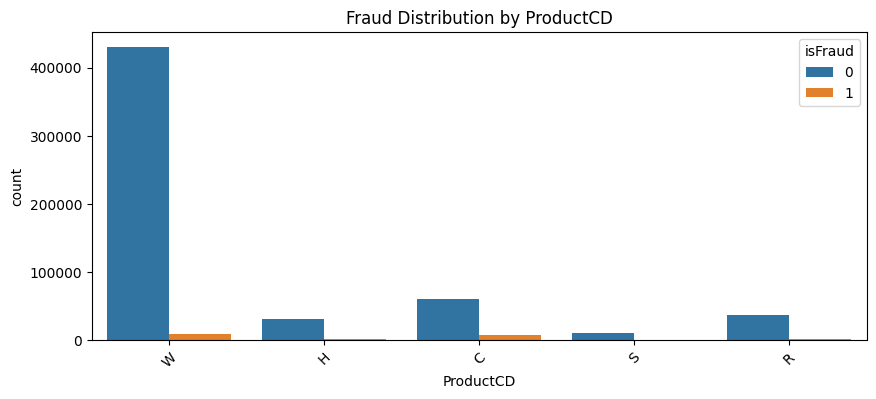

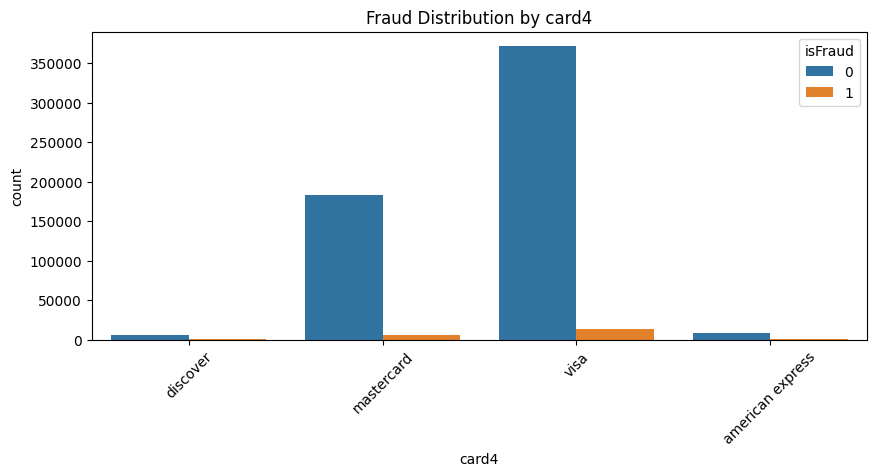

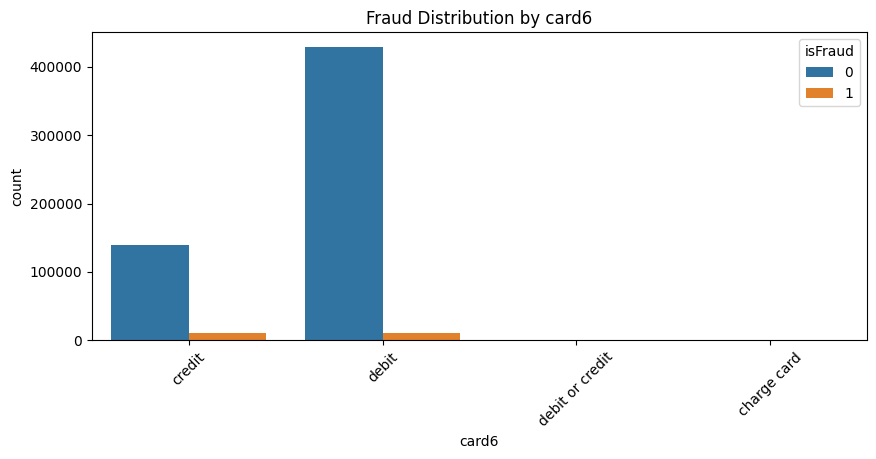

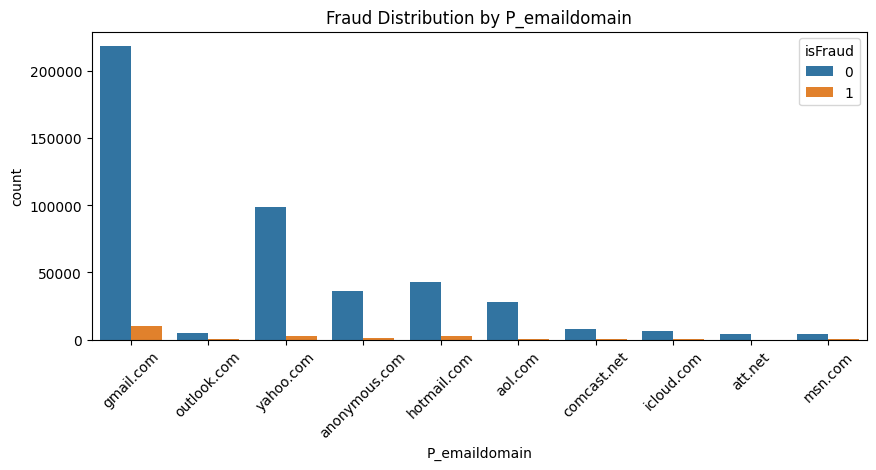

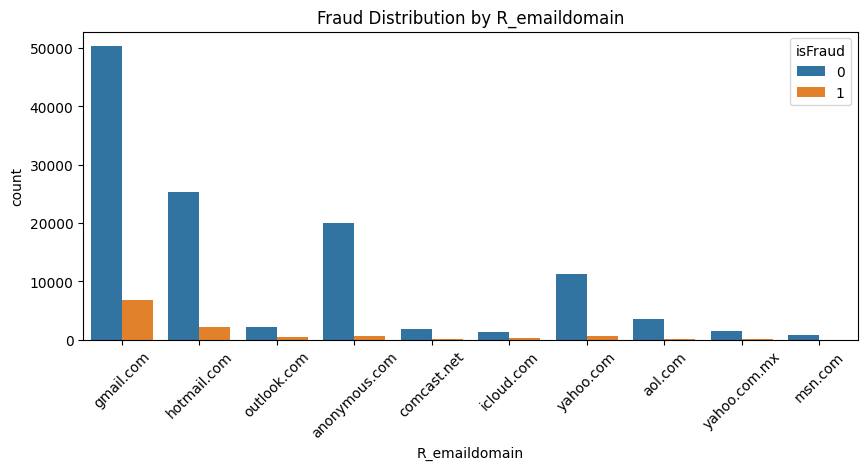

In [12]:
# Categorical columns frequency and fraud rate
cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']
for col in cat_cols:
    top = df[col].value_counts().nlargest(10).index
    temp = df[df[col].isin(top)]
    plt.figure(figsize=(10,4))
    sns.countplot(data=temp, x=col, hue='isFraud')
    plt.title(f'Fraud Distribution by {col}')
    plt.xticks(rotation=45)
    plt.show()

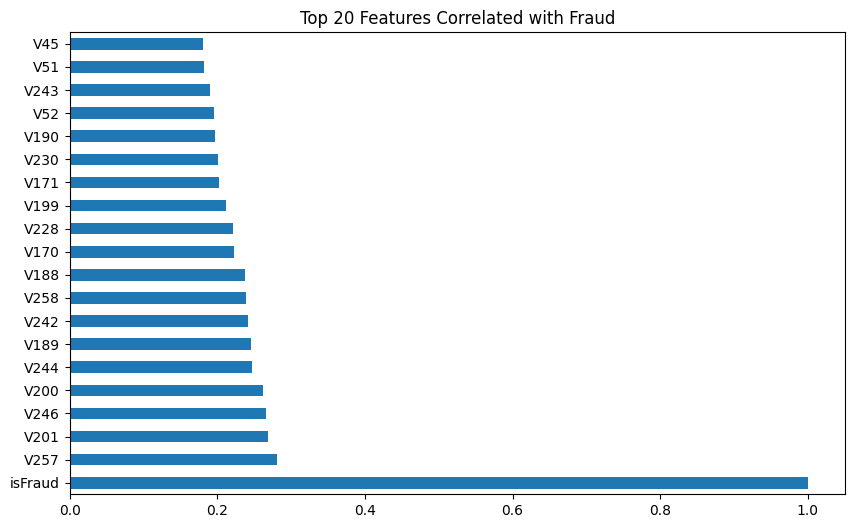

In [13]:
# Correlation heatmap (only numeric)
num_cols = df.select_dtypes(include=[np.number]).drop(columns=['TransactionID', 'TransactionDT']).fillna(0)
corr = num_cols.corrwith(df['isFraud']).sort_values(key=abs, ascending=False)
corr[:20].plot(kind='barh', figsize=(10,6), title='Top 20 Features Correlated with Fraud')
plt.show()

In [15]:
# Optional: Interactive scatter plot with Plotly
fig = px.scatter(df.sample(1000), x='TransactionAmt', y='TransactionDT', color='isFraud',
                 hover_data=['card1', 'addr1', 'P_emaildomain'])
fig.update_layout(title='Transaction Amount vs Time')
fig.show()

# UID Creation and Fraud Rate by UID

In [18]:
import plotly.express as px
from sklearn.decomposition import PCA
import umap

df['uid'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
uid_fraud_rate = df.groupby('uid')['isFraud'].mean().sort_values(ascending=False).head(10)
print("Top UID fraud rates:\n", uid_fraud_rate)


2025-04-29 12:40:12.641028: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745930412.887659      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745930412.966701      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Top UID fraud rates:
 uid
16868_315.0    1.0
18215_170.0    1.0
17363_441.0    1.0
15775_324.0    1.0
15775_264.0    1.0
15775_251.0    1.0
14143_272.0    1.0
14631_203.0    1.0
17363_158.0    1.0
10578_441.0    1.0
Name: isFraud, dtype: float64


# Aggregations by UID

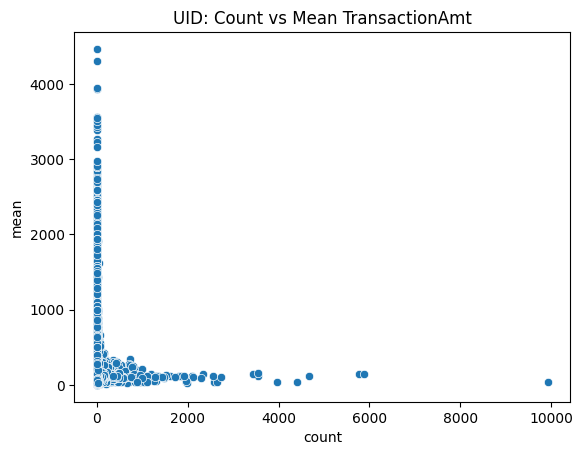

In [19]:
uid_agg = df.groupby('uid')['TransactionAmt'].agg(['mean', 'std', 'count']).reset_index()
sns.scatterplot(data=uid_agg, x='count', y='mean')
plt.title('UID: Count vs Mean TransactionAmt')
plt.show()

# UMAP Visualization

In [3]:
!pip install umap-learn --quiet

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import umap
from sklearn.impute import SimpleImputer

# === Step 1: Select features and scale
df_clean = df.copy()
df_clean = SimpleImputer(strategy='most_frequent').fit_transform(df_clean)

for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].astype(str)
    df_clean[col] = LabelEncoder().fit_transform(df_clean[col])

features = df_clean.drop(columns=['isFraud'])
labels = df_clean['isFraud']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# === Step 2: Apply UMAP
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,       # Lower than default (15 vs 30)
    min_dist=0.1,
    metric='euclidean',
    low_memory=True,      # Use less memory
    random_state=42,
    verbose=True
)
embedding = reducer.fit_transform(X_scaled)

# === Step 3: Create a DataFrame for visualization
umap_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
umap_df['isFraud'] = labels.values

# === Step 4: Plot the UMAP
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=umap_df,
    x='UMAP1', y='UMAP2',
    hue='isFraud',
    palette={0: 'skyblue', 1: 'salmon'},
    alpha=0.6,
    s=10
)
plt.title('UMAP Projection of IEEE-CIS Fraud Detection')
plt.legend(title='isFraud', loc='upper right')
plt.show()

2025-04-29 13:12:59.349689: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745932379.588377      86 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745932379.666078      86 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'numpy.ndarray' object has no attribute 'select_dtypes'

# Feature Drift

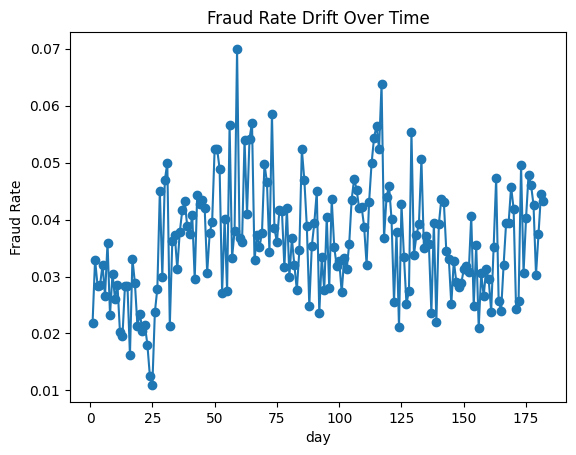

In [9]:
df['day'] = df['TransactionDT'] // (3600 * 24)
daywise = df.groupby('day')['isFraud'].mean()
daywise.plot(title="Fraud Rate Drift Over Time", marker='o')
plt.ylabel("Fraud Rate")
plt.show()

In [5]:
!pip install mlflow dagshub --quiet

In [6]:
import mlflow
from dagshub import dagshub_logger
import os

# Set tracking URI manually
mlflow.set_tracking_uri("https://dagshub.com/ekvirika/FraudDerection.mlflow")

# Use your DagsHub credentials
os.environ["MLFLOW_TRACKING_USERNAME"] = "ekvirika"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "3f601f2c2c7a6bca448ebc69f4f5d4b49daffd8f"

# Optional: set registry if you're using model registry
mlflow.set_registry_uri("https://dagshub.com/ekvirika/FraudDerection.mlflow")

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    average_precision_score, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay
)

# Drop columns with too many missing or ID-type features
X = df.copy()
X = X.drop(columns=['TransactionID', 'TransactionDT', 'isFraud'])
y = df['isFraud']
X = pd.get_dummies(X, dummy_na=True)
X = SimpleImputer(strategy='most_frequent').fit_transform(X)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Train LGBM
import mlflow
import mlflow.lightgbm

mlflow.set_experiment("LightGBM_Training")

with mlflow.start_run(run_name="lightgbm_baseline"):
    model = LGBMClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # AUC Score
    y_pred = model.predict_proba(X_test)[:, 1]
    print(f"ROC AUC: {roc_auc_score(y_test, y_pred):.4f}")
    y_pred_binary = (y_pred >= 0.5).astype(int)

    precision = precision_score(y_test, y_pred_binary)
    recall = recall_score(y_test, y_pred_binary)
    f1 = f1_score(y_test, y_pred_binary)
    avg_precision = average_precision_score(y_test, y_pred)

    print("📊 Evaluation Metrics:")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Average Precision (PR AUC): {avg_precision:.4f}")
    print("\n🔍 Classification Report:")
    print(classification_report(y_test, y_pred_binary))


    cm = confusion_matrix(y_test, y_pred_binary)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # === ROC Curve
    RocCurveDisplay.from_predictions(y_test, y_pred)
    plt.title("ROC Curve")
    plt.show()
    
    # === PR Curve
    PrecisionRecallDisplay.from_predictions(y_test, y_pred)
    plt.title("Precision-Recall Curve")
    plt.show()

    # Plot feature importances
    importances = pd.Series(model.feature_importances_, index=model.booster_.feature_name())
    top_importances = importances.sort_values(ascending=False).head(30)
    top_importances.plot(kind='barh', figsize=(10, 8), title='Top 30 LightGBM Features')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


    mlflow.log_metric("auc", auc)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("average_precision", avg_precision)

    mlflow.lightgbm.log_model(model, "model")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("train_size", len(X_train))
    mlflow.log_param("test_size", len(X_test))

    print("Logged LightGBM model to MLflow.")